In [17]:
from google.colab import files
# csv data from https://data.krx.co.kr/contents/MDC/MAIN/main/index.cmd #
uploaded = files.upload()

Saving Sam.csv to Sam (1).csv
Saving SK.csv to SK (1).csv


In [18]:
import os
print(os.listdir())

['.config', 'Sam (1).csv', 'Sam.csv', 'SK.csv', 'SK (1).csv', 'sample_data']


In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import Adam


class StockPredictor:
    def __init__(self, file_name, window_size=5):
        self.file_name = file_name
        self.window_size = window_size
        self.data = None

        # Scaler for input features
        self.scaler = MinMaxScaler()

        # Scaler for target closing price
        self.target_scaler = MinMaxScaler()

        self.model = None

    def load_data(self):
        """
        Load and clean KRX Korean CSV file.
        """
        self.data = pd.read_csv(self.file_name, encoding="cp949")

        # Remove spaces from column names
        self.data.columns = self.data.columns.str.strip()

        # Rename Korean column names to English column names
        self.data = self.data.rename(columns={
            "일자": "Date",
            "날짜": "Date",
            "시가": "Open",
            "고가": "High",
            "저가": "Low",
            "종가": "Close",
            "거래량": "Volume"
        })

        # Use only necessary columns
        required_columns = ["Date", "Open", "High", "Low", "Close", "Volume"]
        self.data = self.data[required_columns]

        # Convert date format
        self.data["Date"] = pd.to_datetime(self.data["Date"])

        # Convert numeric columns
        numeric_columns = ["Open", "High", "Low", "Close", "Volume"]

        for col in numeric_columns:
            self.data[col] = (
                self.data[col]
                .astype(str)
                .str.replace(",", "", regex=False)
                .astype(float)
            )

        # Remove duplicate dates
        self.data = self.data.drop_duplicates(subset=["Date"])

        # Sort by date from past to present
        self.data = self.data.sort_values("Date")

        # Remove missing values
        self.data = self.data.dropna()

        print("Data loading completed.")
        print(self.data.head())
        print()
        print("Number of data points:", len(self.data))

    def make_features(self):
        """
        Add moving averages and price change features.
        """
        self.data["MA5"] = self.data["Close"].rolling(window=5).mean()
        self.data["MA10"] = self.data["Close"].rolling(window=10).mean()
        self.data["Change"] = self.data["Close"].pct_change()

        self.data = self.data.dropna()

        print()
        print("Feature engineering completed.")
        print(self.data[["Date", "Close", "MA5", "MA10", "Change"]].head())

    def create_dataset(self):
        """
        Create input X using recent window_size days,
        and target y using the next day's closing price.
        """
        feature_columns = [
            "Open", "High", "Low", "Close", "Volume",
            "MA5", "MA10", "Change"
        ]

        feature_data = self.data[feature_columns].values
        close_data = self.data[["Close"]].values

        # Normalize input features
        scaled_features = self.scaler.fit_transform(feature_data)

        # Normalize target closing price
        scaled_close = self.target_scaler.fit_transform(close_data)

        X = []
        y = []

        for i in range(self.window_size, len(scaled_features)):
            X.append(scaled_features[i - self.window_size:i].flatten())
            y.append(scaled_close[i][0])

        X = np.array(X)
        y = np.array(y)

        print()
        print("Training dataset creation completed.")
        print("X shape:", X.shape)
        print("y shape:", y.shape)

        return X, y

    def build_model(self, input_size):
        """
        Build artificial neural network model.
        """
        self.model = Sequential()

        self.model.add(Dense(64, activation="relu", input_shape=(input_size,)))
        self.model.add(Dense(32, activation="relu"))
        self.model.add(Dense(16, activation="relu"))
        self.model.add(Dense(1))

        self.model.compile(
            optimizer=Adam(learning_rate=0.001),
            loss="mse"
        )

        print()
        print("Model construction completed.")
        self.model.summary()

    def train_model(self, X_train, y_train, X_test, y_test):
        """
        Train the model.
        """
        print()
        print("Model training started.")

        history = self.model.fit(
            X_train,
            y_train,
            epochs=100,
            batch_size=16,
            validation_data=(X_test, y_test),
            verbose=1
        )

        return history

    def evaluate_model(self, X_test, y_test):
        """
        Compare actual and predicted closing prices and calculate errors.
        """
        scaled_predictions = self.model.predict(X_test).flatten()

        predictions = self.target_scaler.inverse_transform(
            scaled_predictions.reshape(-1, 1)
        ).flatten()

        y_test_real = self.target_scaler.inverse_transform(
            y_test.reshape(-1, 1)
        ).flatten()

        mae = mean_absolute_error(y_test_real, predictions)
        mse = mean_squared_error(y_test_real, predictions)
        rmse = np.sqrt(mse)

        print()
        print("Model Evaluation Results")
        print(f"MAE  : {mae:.2f} KRW")
        print(f"MSE  : {mse:.2f}")
        print(f"RMSE : {rmse:.2f} KRW")

        return predictions, mae, mse, rmse, y_test_real

    def plot_loss(self, history):
        """
        Plot training loss and validation loss.
        """
        plt.figure(figsize=(10, 5))
        plt.plot(history.history["loss"], label="Training Loss")
        plt.plot(history.history["val_loss"], label="Validation Loss")
        plt.title("Training Loss and Validation Loss")
        plt.xlabel("Epoch")
        plt.ylabel("Loss")
        plt.legend()
        plt.grid()
        plt.show()

    def plot_result(self, y_test_real, predictions):
        """
        Plot actual and predicted closing prices.
        """
        plt.figure(figsize=(12, 5))
        plt.plot(y_test_real, label="Real Close Price")
        plt.plot(predictions, label="Predicted Close Price")
        plt.title("Real Stock Price vs Predicted Stock Price")
        plt.xlabel("Test Data Index")
        plt.ylabel("Close Price")
        plt.legend()
        plt.grid()
        plt.show()

    def predict_next_day(self):
        """
        Predict the closing price for the next trading day.
        """
        feature_columns = [
            "Open", "High", "Low", "Close", "Volume",
            "MA5", "MA10", "Change"
        ]

        recent_data = self.data[feature_columns].values[-self.window_size:]
        scaled_recent_data = self.scaler.transform(recent_data)

        X_recent = scaled_recent_data.flatten().reshape(1, -1)

        scaled_predicted_price = self.model.predict(X_recent, verbose=0)[0][0]

        predicted_price = self.target_scaler.inverse_transform(
            np.array([[scaled_predicted_price]])
        )[0][0]

        print()
        print(f"Predicted closing price for the next trading day: {predicted_price:.2f} KRW")

        return predicted_price

    def predict_future_days(self, days=20):

        feature_columns = [
            "Open", "High", "Low", "Close", "Volume",
            "MA5", "MA10", "Change"
        ]

        future_data = self.data.copy()
        future_prices = []
        future_dates = []

        if len(future_data) < self.window_size:
            raise ValueError("Not enough data for future prediction.")

        for _ in range(days):
            recent_data = future_data[feature_columns].values[-self.window_size:]
            scaled_recent_data = self.scaler.transform(recent_data)

            X_recent = scaled_recent_data.flatten().reshape(1, -1)

            scaled_predicted_close = self.model.predict(X_recent, verbose=0)[0][0]

            predicted_close = self.target_scaler.inverse_transform(
                np.array([[scaled_predicted_close]])
            )[0][0]

            last_date = future_data["Date"].iloc[-1]
            next_date = last_date + pd.Timedelta(days=1)

            # Skip weekends
            while next_date.weekday() >= 5:
                next_date += pd.Timedelta(days=1)

            future_prices.append(predicted_close)
            future_dates.append(next_date)

            new_row = {
                "Date": next_date,
                "Open": predicted_close,
                "High": predicted_close,
                "Low": predicted_close,
                "Close": predicted_close,
                "Volume": future_data["Volume"].iloc[-1],
                "MA5": np.nan,
                "MA10": np.nan,
                "Change": np.nan
            }

            future_data = pd.concat(
                [future_data, pd.DataFrame([new_row])],
                ignore_index=True
            )

            future_data["MA5"] = future_data["Close"].rolling(window=5).mean()
            future_data["MA10"] = future_data["Close"].rolling(window=10).mean()
            future_data["Change"] = future_data["Close"].pct_change()

            # Do not drop rows during iterative future prediction
            future_data[["MA5", "MA10", "Change"]] = (
                future_data[["MA5", "MA10", "Change"]]
                .bfill()
                .ffill()
            )

        return future_dates, future_prices

    def plot_future_prediction(self, days=20):
        """
        Plot future predicted closing prices after real stock price data.
        """
        future_dates, future_prices = self.predict_future_days(days=days)

        plt.figure(figsize=(12, 5))

        plt.plot(
            self.data["Date"],
            self.data["Close"],
            label="Real Close Price"
        )

        plt.plot(
            future_dates,
            future_prices,
            linestyle="--",
            marker="o",
            label="Future Predicted Price"
        )

        plt.title("Real Stock Price and Future Predicted Stock Price")
        plt.xlabel("Date")
        plt.ylabel("Close Price")
        plt.legend()
        plt.grid()
        plt.xticks(rotation=45)
        plt.show()

        print()
        print(f"Prediction of closing prices for the next {days} trading days")
        for date, price in zip(future_dates, future_prices):
            print(f"{date.date()} predicted closing price: {price:.2f} KRW")

        return future_dates, future_prices

    def run(self):
        """
        Full execution pipeline.
        """
        self.load_data()
        self.make_features()

        X, y = self.create_dataset()

        X_train, X_test, y_train, y_test = train_test_split(
            X,
            y,
            test_size=0.2,
            shuffle=False
        )

        print()
        print("Train/Test split completed.")
        print("Train data:", X_train.shape)
        print("Test data :", X_test.shape)

        self.build_model(input_size=X_train.shape[1])

        history = self.train_model(X_train, y_train, X_test, y_test)

        predictions, mae, mse, rmse, y_test_real = self.evaluate_model(X_test, y_test)

        self.plot_loss(history)
        self.plot_result(y_test_real, predictions)

        next_price = self.predict_next_day()

        future_dates, future_prices = self.plot_future_prediction(days=20)

        return predictions, mae, mse, rmse, next_price, future_dates, future_prices

Data loading completed.
         Date      Open      High       Low     Close      Volume
21 2026-05-12  290000.0  291500.0  266000.0  279000.0  41211149.0
20 2026-05-13  264000.0  285500.0  262000.0  284000.0  35540134.0
19 2026-05-14  282000.0  299500.0  282000.0  296000.0  39314752.0
18 2026-05-15  291000.0  296500.0  266000.0  270500.0  38075487.0
17 2026-05-18  269500.0  288500.0  262000.0  281000.0  33555214.0

Number of data points: 22

Feature engineering completed.
         Date     Close       MA5      MA10    Change
12 2026-05-26  299000.0  288500.0  285300.0  0.022222
11 2026-05-27  307000.0  294800.0  288100.0  0.026756
10 2026-05-28  299500.0  299500.0  289650.0 -0.024430
9  2026-05-29  317000.0  303000.0  291750.0  0.058431
8  2026-06-01  349000.0  314300.0  299600.0  0.100946

Training dataset creation completed.
X shape: (8, 40)
y shape: (8,)

Train/Test split completed.
Train data: (6, 40)
Test data : (2, 40)

Model construction completed.


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_9"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_36 (Dense)                │ (None, 64)             │         2,624 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_37 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_38 (Dense)                │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_39 (Dense)                │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,249 (20.50 KB)

 Trainable params: 5,249 (20.50 KB)

 Non-trainable params: 0 (0.00 B)


Model training started.
Epoch 1/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step - loss: 0.9477 - val_loss: 0.4047
Epoch 2/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 89ms/step - loss: 0.8161 - val_loss: 0.3343
Epoch 3/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step - loss: 0.7118 - val_loss: 0.2754
Epoch 4/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 88ms/step - loss: 0.6286 - val_loss: 0.2226
Epoch 5/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step - loss: 0.5563 - val_loss: 0.1793
Epoch 6/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 142ms/step - loss: 0.4940 - val_loss: 0.1434
Epoch 7/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step - loss: 0.4433 - val_loss: 0.1126
Epoch 8/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 94ms/step - loss: 0.4025 - val_loss: 0.0878
Epoch 9/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step - loss: 0.3683 - val_loss: 0.0717
Epoch 10/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step - loss: 0.3510 - val_loss: 0.0661
Epoch 11/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step - loss: 0.3400 - val_loss: 0.0640
Epoch 12/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step

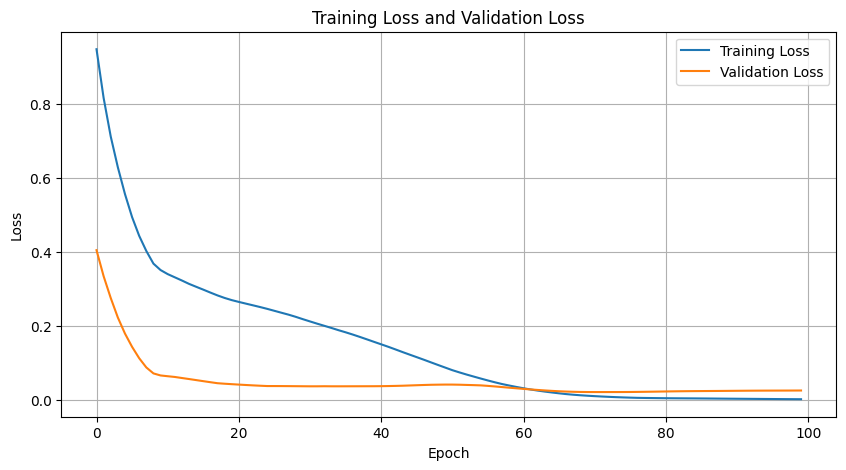

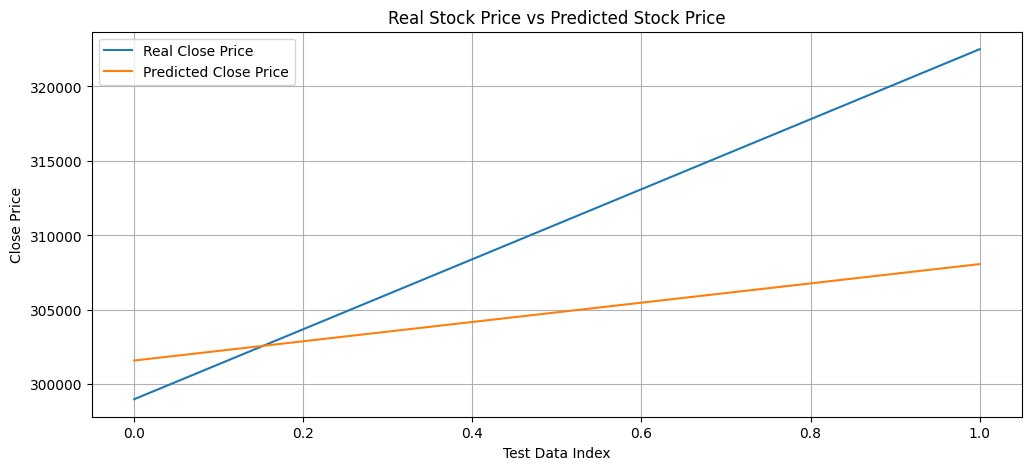


Predicted closing price for the next trading day: 319609.12 KRW


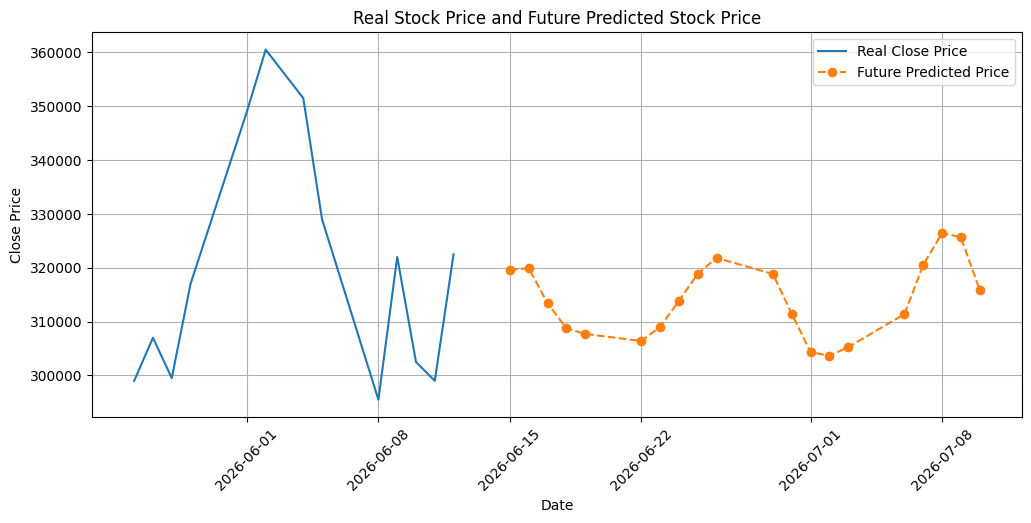


Prediction of closing prices for the next 20 trading days
2026-06-15 predicted closing price: 319609.12 KRW
2026-06-16 predicted closing price: 319928.44 KRW
2026-06-17 predicted closing price: 313418.12 KRW
2026-06-18 predicted closing price: 308766.72 KRW
2026-06-19 predicted closing price: 307718.16 KRW
2026-06-22 predicted closing price: 306384.22 KRW
2026-06-23 predicted closing price: 309066.44 KRW
2026-06-24 predicted closing price: 313871.75 KRW
2026-06-25 predicted closing price: 318891.12 KRW
2026-06-26 predicted closing price: 321839.62 KRW
2026-06-29 predicted closing price: 318831.75 KRW
2026-06-30 predicted closing price: 311472.88 KRW
2026-07-01 predicted closing price: 304333.06 KRW
2026-07-02 predicted closing price: 303656.72 KRW
2026-07-03 predicted closing price: 305244.25 KRW
2026-07-06 predicted closing price: 311392.25 KRW
2026-07-07 predicted closing price: 320513.75 KRW
2026-07-08 predicted closing price: 326458.34 KRW
2026-07-09 predicted closing price: 32565

In [24]:
samsung_predictor = StockPredictor("Sam.csv", window_size=5)
samsung_result = samsung_predictor.run()

Data loading completed.
         Date       Open       High        Low      Close     Volume
21 2026-05-12  1944000.0  1967000.0  1804000.0  1835000.0  9160593.0
20 2026-05-13  1781000.0  1990000.0  1781000.0  1976000.0  7126921.0
19 2026-05-14  1976000.0  1994000.0  1937000.0  1970000.0  6040068.0
18 2026-05-15  1950000.0  1995000.0  1789000.0  1819000.0  7485233.0
17 2026-05-18  1780000.0  1897000.0  1731000.0  1840000.0  6481608.0

Number of data points: 22

Feature engineering completed.
         Date      Close        MA5       MA10    Change
12 2026-05-26  2052000.0  1884600.0  1886300.0  0.057187
11 2026-05-27  2243000.0  1984200.0  1927100.0  0.093080
10 2026-05-28  2289000.0  2093000.0  1958400.0  0.020508
9  2026-05-29  2333000.0  2171600.0  1994700.0  0.019222
8  2026-06-01  2363000.0  2256000.0  2049100.0  0.012859

Training dataset creation completed.
X shape: (8, 40)
y shape: (8,)

Train/Test split completed.
Train data: (6, 40)
Test data : (2, 40)

Model construction com

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_8"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_32 (Dense)                │ (None, 64)             │         2,624 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_33 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_34 (Dense)                │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_35 (Dense)                │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,249 (20.50 KB)

 Trainable params: 5,249 (20.50 KB)

 Non-trainable params: 0 (0.00 B)


Model training started.
Epoch 1/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step - loss: 0.3472 - val_loss: 0.0057
Epoch 2/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 137ms/step - loss: 0.2572 - val_loss: 0.0017
Epoch 3/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 111ms/step - loss: 0.1980 - val_loss: 0.0173
Epoch 4/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step - loss: 0.1594 - val_loss: 0.0361
Epoch 5/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step - loss: 0.1425 - val_loss: 0.0478
Epoch 6/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 95ms/step - loss: 0.1339 - val_loss: 0.0484
Epoch 7/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step - loss: 0.1250 - val_loss: 0.0401
Epoch 8/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step - loss: 0.1100 - val_loss: 0.0272
Epoch 9/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step - loss: 0.0901 - val_loss: 0.0145
Epoch 10/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 87ms/step - loss: 0.0724 - val_loss: 0.0052
Epoch 11/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 84ms/step - loss: 0.0596 - val_loss: 0.0018
Epoch 12/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 85ms/ste

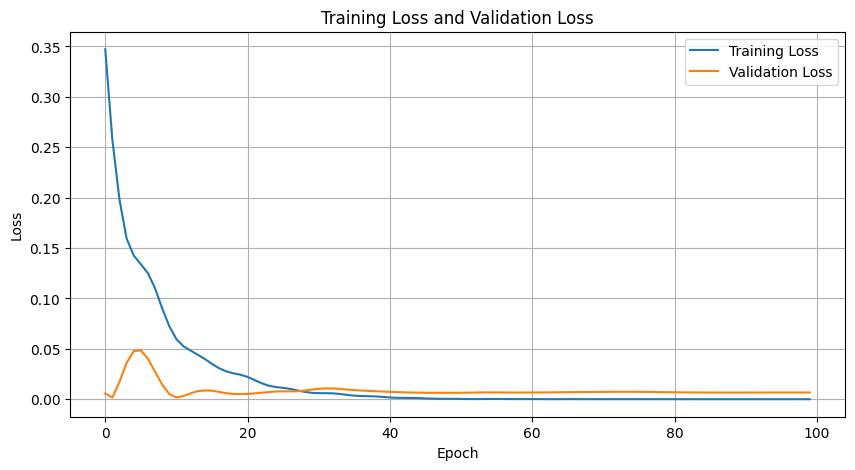

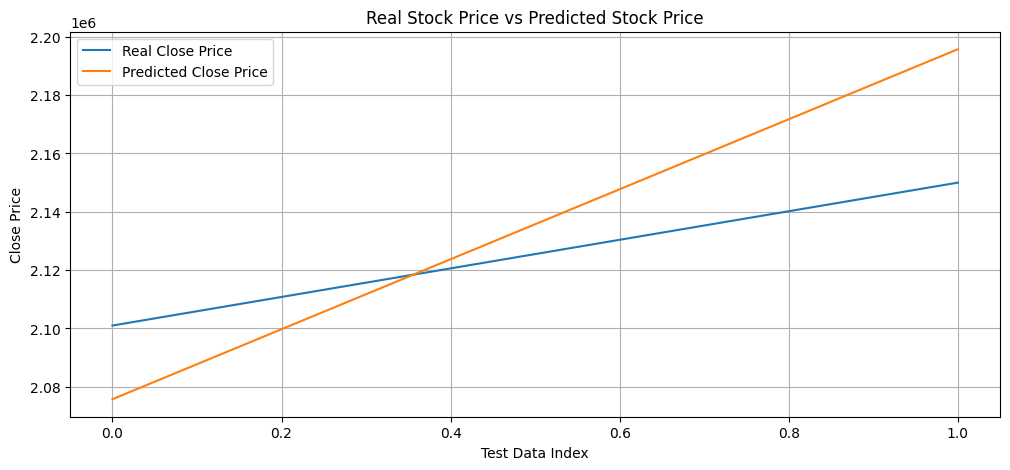


Predicted closing price for the next trading day: 1932883.50 KRW


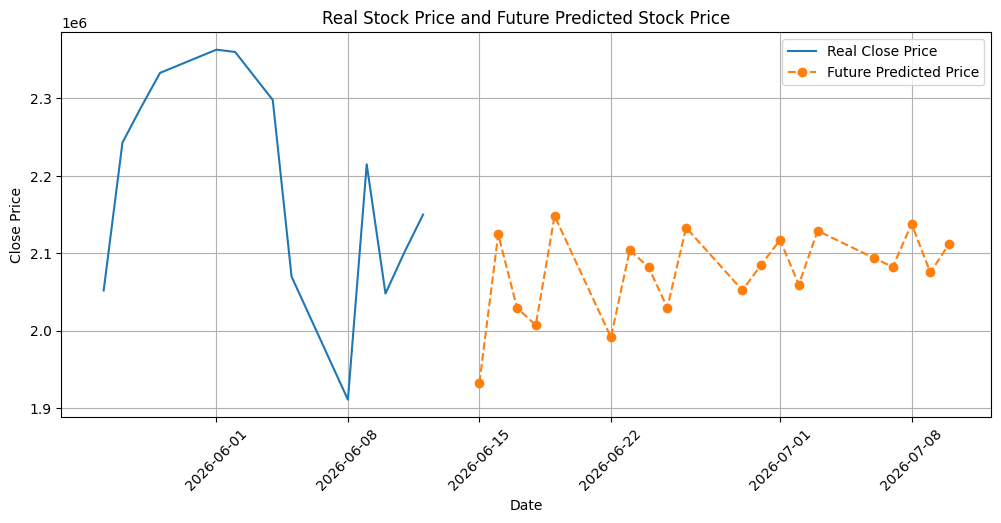


Prediction of closing prices for the next 20 trading days
2026-06-15 predicted closing price: 1932883.50 KRW
2026-06-16 predicted closing price: 2124650.00 KRW
2026-06-17 predicted closing price: 2029588.12 KRW
2026-06-18 predicted closing price: 2007226.88 KRW
2026-06-19 predicted closing price: 2148278.25 KRW
2026-06-22 predicted closing price: 1991616.00 KRW
2026-06-23 predicted closing price: 2104229.75 KRW
2026-06-24 predicted closing price: 2081996.88 KRW
2026-06-25 predicted closing price: 2029771.12 KRW
2026-06-26 predicted closing price: 2133131.75 KRW
2026-06-29 predicted closing price: 2052184.75 KRW
2026-06-30 predicted closing price: 2085432.62 KRW
2026-07-01 predicted closing price: 2117203.25 KRW
2026-07-02 predicted closing price: 2059615.62 KRW
2026-07-03 predicted closing price: 2129111.50 KRW
2026-07-06 predicted closing price: 2093939.62 KRW
2026-07-07 predicted closing price: 2082321.00 KRW
2026-07-08 predicted closing price: 2137992.50 KRW
2026-07-09 predicted cl

In [23]:
samsung_predictor = StockPredictor("SK.csv", window_size=5)
samsung_result = samsung_predictor.run()